In [1]:
# source-cells: 0
# 套件由教學環境統一安裝；本章不執行舊 imread plugin 安裝。

In [2]:
# source-cells: 1
from pathlib import Path
import sys
import numpy as np
import matplotlib.pyplot as plt
import skimage as ski
import pywt
from skimage.restoration import denoise_wavelet, estimate_sigma
from skimage.metrics import peak_signal_noise_ratio
from skimage.util import random_noise

BOOK = Path('book') if Path('book').is_dir() else Path('.')
sys.path.insert(0, str(BOOK.resolve()))
from _support import image_path, show_images, diagram

plt.rcParams['image.cmap'] = 'gray'

In [3]:
# source-cells: 2

# 小波分析：從時間與尺度到影像去雜訊

上一章用 Fourier 表示頻率，並用金字塔分開影像尺度。本章把分析函數放到訊號的不同位置，再調整它的尺度，觀察局部變化。先比較時間與頻率的取捨，再從小波家族、ECG 分解走到 Lucario 影像的四子帶與去雜訊。

In [4]:
# source-cells: 3

## 為什麼還需要局部的頻率描述？

全域 Fourier transform 描述整段訊號的頻率組成；完整的複數係數仍可還原訊號，時間資訊保存在相位關係中。不過，全域振幅頻譜沒有直接標出每種頻率出現的時間。

下面比較四個頻率（4、30、60、90 Hz）全程同時存在，與依序各出現四分之一段的情形。兩張頻譜都在這些頻率附近有能量，但峰高與頻譜洩漏會不同，完整 Fourier transform 可以區分兩個訊號。有限觀測長度也限制頻率解析能力。

**短時傅立葉轉換（STFT）**先用移動視窗截取訊號，再逐窗計算 Fourier transform。這讓頻譜帶有時間位置，但定位精度受視窗寬度限制。例如將訊號分成 10 個不重疊區間，第二個區間對應總時長的 1/10 到 2/10；頻率在該窗出現，仍無法由單一窗確定更精細的起止時間。

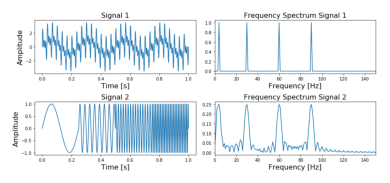

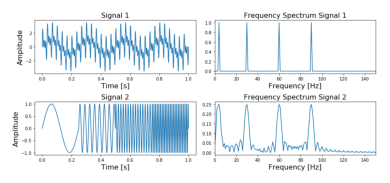

In [5]:
# source-cells: 3
# 原教學示意圖：https://drive.google.com/uc?id=1C8ITJkJtXxewppV0I-7AGm2qHRYCkk_J
show_images(ski.io.imread(image_path('ch04-cell3-1.png')))

In [6]:
# source-cells: 4

## STFT 與小波的解析度取捨

STFT 使用固定寬度的視窗。短窗能較精細地定位時間，卻較難分開相近頻率；長窗則相反。小波使用可伸縮的分析函數：大尺度涵蓋較長時間、適合分析低頻；小尺度涵蓋較短時間、適合定位高頻的短暫變化。

下圖以格子示意各種表示的分析範圍。小波沒有同時取得任意高的時間與頻率解析度，而是讓取捨隨尺度改變：低頻處通常有較細頻率解析、較粗時間定位，高頻處則有較細時間定位、較粗頻率解析。原始時間序列和完整 Fourier 表示都保有訊號資訊，差別在於哪些特徵容易直接讀出。

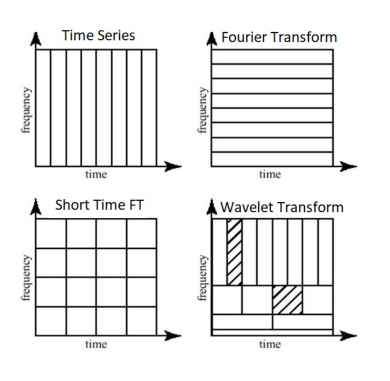

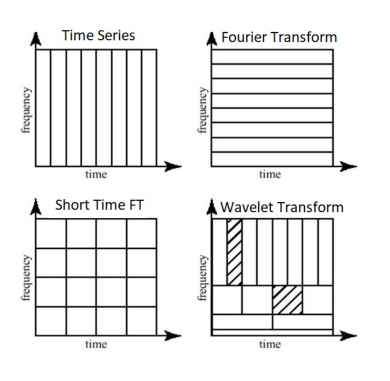

In [7]:
# source-cells: 4
# 原教學示意圖：https://drive.google.com/uc?id=1C8ZHTWEzMP2ccNgVxkuE6ShcRu4ut9JT
show_images(ski.io.imread(image_path('ch04-cell4-1.png')))

In [8]:
# source-cells: 5

## 小波如何分析訊號？

In [9]:
# source-cells: 6

Fourier 基底的正弦波延伸到整個時間軸；小波則是集中在有限區間或快速衰減的局部振盪。把小波移到不同位置，和訊號計算內積，便能量出該位置含有多少相似的局部形狀。

固定尺度後沿時間移動，這個內積可寫成和反轉共軛核的卷積；再改變尺度，便得到時間與尺度兩個軸。這種圖稱為 **scalogram（尺度圖）**。尺度越大通常對應越低頻率，但確切的 pseudo-frequency 需要母小波與取樣週期共同換算；例如 PyWavelets 可用 `scale2frequency(wavelet, scale) / sampling_period` 取得 Hz。

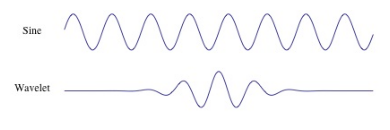

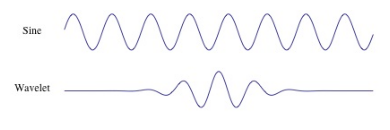

In [10]:
# source-cells: 6
# 原教學示意圖：https://drive.google.com/uc?id=1C8pVteFtFA2ElDVq-tTAuSEc4hqIToOX
show_images(ski.io.imread(image_path('ch04-cell6-1.png')))

In [11]:
# source-cells: 7

### 連續小波轉換的式子

對訊號 $h(t)$，連續小波轉換（CWT）寫成

$$W(a,b)=\frac{1}{\sqrt{|a|}}\int h(t)\overline{\psi\!\left(\frac{t-b}{a}\right)}\,dt.$$

$\psi$ 是母小波，$a$ 決定伸縮尺度，$b$ 決定平移位置，前面的因子補償伸縮造成的能量變化。連續模型允許尺度和平移連續改變，電腦則在選定網格上計算。

常見的 dyadic family 選 $a=2^j$、$b=k2^j$，得到 $\psi_{j,k}(t)=2^{-j/2}\psi(2^{-j}t-k)$。尺度變大時，平移網格也跟著變粗。可逆的離散小波轉換（DWT）還需要合適的分析與合成濾波器，並非任意離散取幾個 CWT 係數即可。

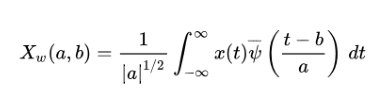

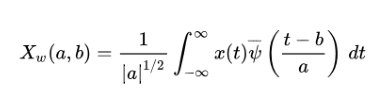

In [12]:
# source-cells: 7
# 原教學示意圖：https://drive.google.com/uc?id=1UBQ-rJAtcM8GxzzkOvKcS47Z2ZGM2K9S
show_images(ski.io.imread(image_path('ch04-cell7-1.png')))

In [13]:
# source-cells: 8

## 小波家族

In [14]:
# source-cells: 9

小波的支撐長度、平滑性、對稱性與消失動差會影響它對局部形狀的反應。[PyWavelets 文件](https://pywavelets.readthedocs.io/en/latest/)整理了各家族與參數；[Wavelet Browser](http://wavelets.pybytes.com/)提供家族圖形，可與下面的程式結果對照。先列出目前安裝版本提供的連續與離散小波，再看每個家族的成員。

In [15]:
# source-cells: 10
wavelet_families = pywt.families(short=False)
discrete_mother_wavelets = pywt.wavelist(kind='discrete')
continuous_mother_wavelets = pywt.wavelist(kind='continuous')

print("PyWavelets contains the following Continuous families: ")
print(continuous_mother_wavelets)
print()
print("PyWavelets contains the following Discrete families: ")
print(discrete_mother_wavelets)
print()
for family in pywt.families():
    print("    * The {} family contains: {}".format(family, pywt.wavelist(family)))

PyWavelets contains the following Continuous families: 
['cgau1', 'cgau2', 'cgau3', 'cgau4', 'cgau5', 'cgau6', 'cgau7', 'cgau8', 'cmor', 'fbsp', 'gaus1', 'gaus2', 'gaus3', 'gaus4', 'gaus5', 'gaus6', 'gaus7', 'gaus8', 'mexh', 'morl', 'shan']

PyWavelets contains the following Discrete families: 
['bior1.1', 'bior1.3', 'bior1.5', 'bior2.2', 'bior2.4', 'bior2.6', 'bior2.8', 'bior3.1', 'bior3.3', 'bior3.5', 'bior3.7', 'bior3.9', 'bior4.4', 'bior5.5', 'bior6.8', 'coif1', 'coif2', 'coif3', 'coif4', 'coif5', 'coif6', 'coif7', 'coif8', 'coif9', 'coif10', 'coif11', 'coif12', 'coif13', 'coif14', 'coif15', 'coif16', 'coif17', 'db1', 'db2', 'db3', 'db4', 'db5', 'db6', 'db7', 'db8', 'db9', 'db10', 'db11', 'db12', 'db13', 'db14', 'db15', 'db16', 'db17', 'db18', 'db19', 'db20', 'db21', 'db22', 'db23', 'db24', 'db25', 'db26', 'db27', 'db28', 'db29', 'db30', 'db31', 'db32', 'db33', 'db34', 'db35', 'db36', 'db37', 'db38', 'dmey', 'haar', 'rbio1.1', 'rbio1.3', 'rbio1.5', 'rbio2.2', 'rbio2.4', 'rbio2.6', 

In [16]:
# source-cells: 11

有限能量 $\int|\psi(t)|^2dt<\infty$ 讓小波可與平方可積訊號取內積；零平均 $\int\psi(t)dt=0$ 則讓它不回應常數背景。有限能量本身不保證緊支撐，也不等同於絕對可積。常把母小波正規化成單位能量，以便比較尺度。

```{dropdown} 零平均與 CWT 可逆性還差什麼？
CWT 的可容許條件通常寫成

$$0<C_\psi=\int_{-\infty}^{\infty}\frac{|\widehat\psi(\omega)|^2}{|\omega|}\,d\omega<\infty.$$

在常用的正則條件下，它要求零頻率處的響應為零。零平均與有限能量並不足以單獨保證這個積分有限；還要考慮頻譜在零頻率附近與遠端的行為。局部性、平滑性與可逆性因此需要分開檢查。
```

In [17]:
# source-cells: 12

下面第一列是 `db5`、`sym5`、`coif5`、`bior2.4`，第二列是 `mexh`、`morl`、`cgau5`、`gaus5`。離散小波的 `wavefun()` 同時回傳 scaling function 與 wavelet；圖中取小波 $\psi$。雙正交家族另有分析與合成小波，複數小波則分開畫實部與虛部。

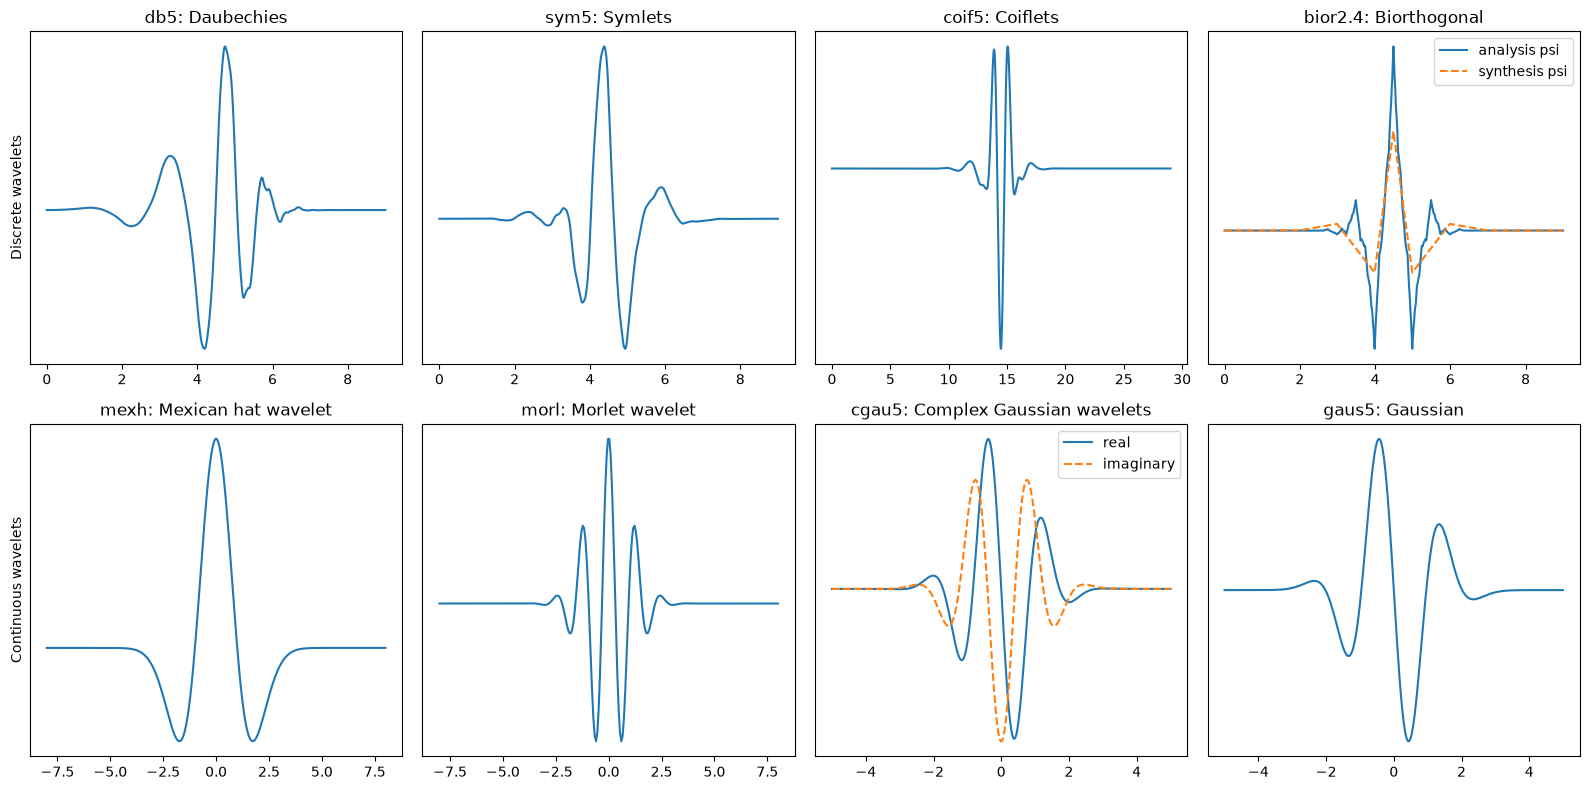

In [18]:
# source-cells: 13
discrete_wavelets = ['db5', 'sym5', 'coif5', 'bior2.4']
continuous_wavelets = ['mexh', 'morl', 'cgau5', 'gaus5']
fig, axarr = plt.subplots(nrows=2, ncols=4, figsize=(16, 8))
for column, name in enumerate(discrete_wavelets):
    wavelet = pywt.Wavelet(name)
    functions = wavelet.wavefun()
    if wavelet.orthogonal:
        phi, psi, x_values = functions
        axarr[0, column].plot(x_values, psi, label='wavelet psi')
    else:
        phi_d, psi_d, phi_r, psi_r, x_values = functions
        axarr[0, column].plot(x_values, psi_d, label='analysis psi')
        axarr[0, column].plot(x_values, psi_r, '--', label='synthesis psi')
        axarr[0, column].legend()
    axarr[0, column].set_title(f'{name}: {wavelet.family_name}')
for column, name in enumerate(continuous_wavelets):
    wavelet = pywt.ContinuousWavelet(name)
    psi, x_values = wavelet.wavefun()
    axarr[1, column].plot(x_values, psi.real, label='real')
    if np.iscomplexobj(psi):
        axarr[1, column].plot(x_values, psi.imag, '--', label='imaginary')
        axarr[1, column].legend()
    axarr[1, column].set_title(f'{name}: {wavelet.family_name}')
axarr[0, 0].set_ylabel('Discrete wavelets')
axarr[1, 0].set_ylabel('Continuous wavelets')
for ax in axarr.flat:
    ax.set_yticks([])
fig.tight_layout()
plt.show()

In [19]:
# source-cells: 14

### 同一家族的階數與取樣精細度

濾波器係數數目、消失動差數目與分解層數是不同量。以 Daubechies 的 `dbN` 為例，N 表示消失動差數，濾波器長度為 2N。下面用 `db1` 到 `db5`，分別在 `wavefun(level=1)` 到 `level=5` 畫出母小波，共 25 張圖。

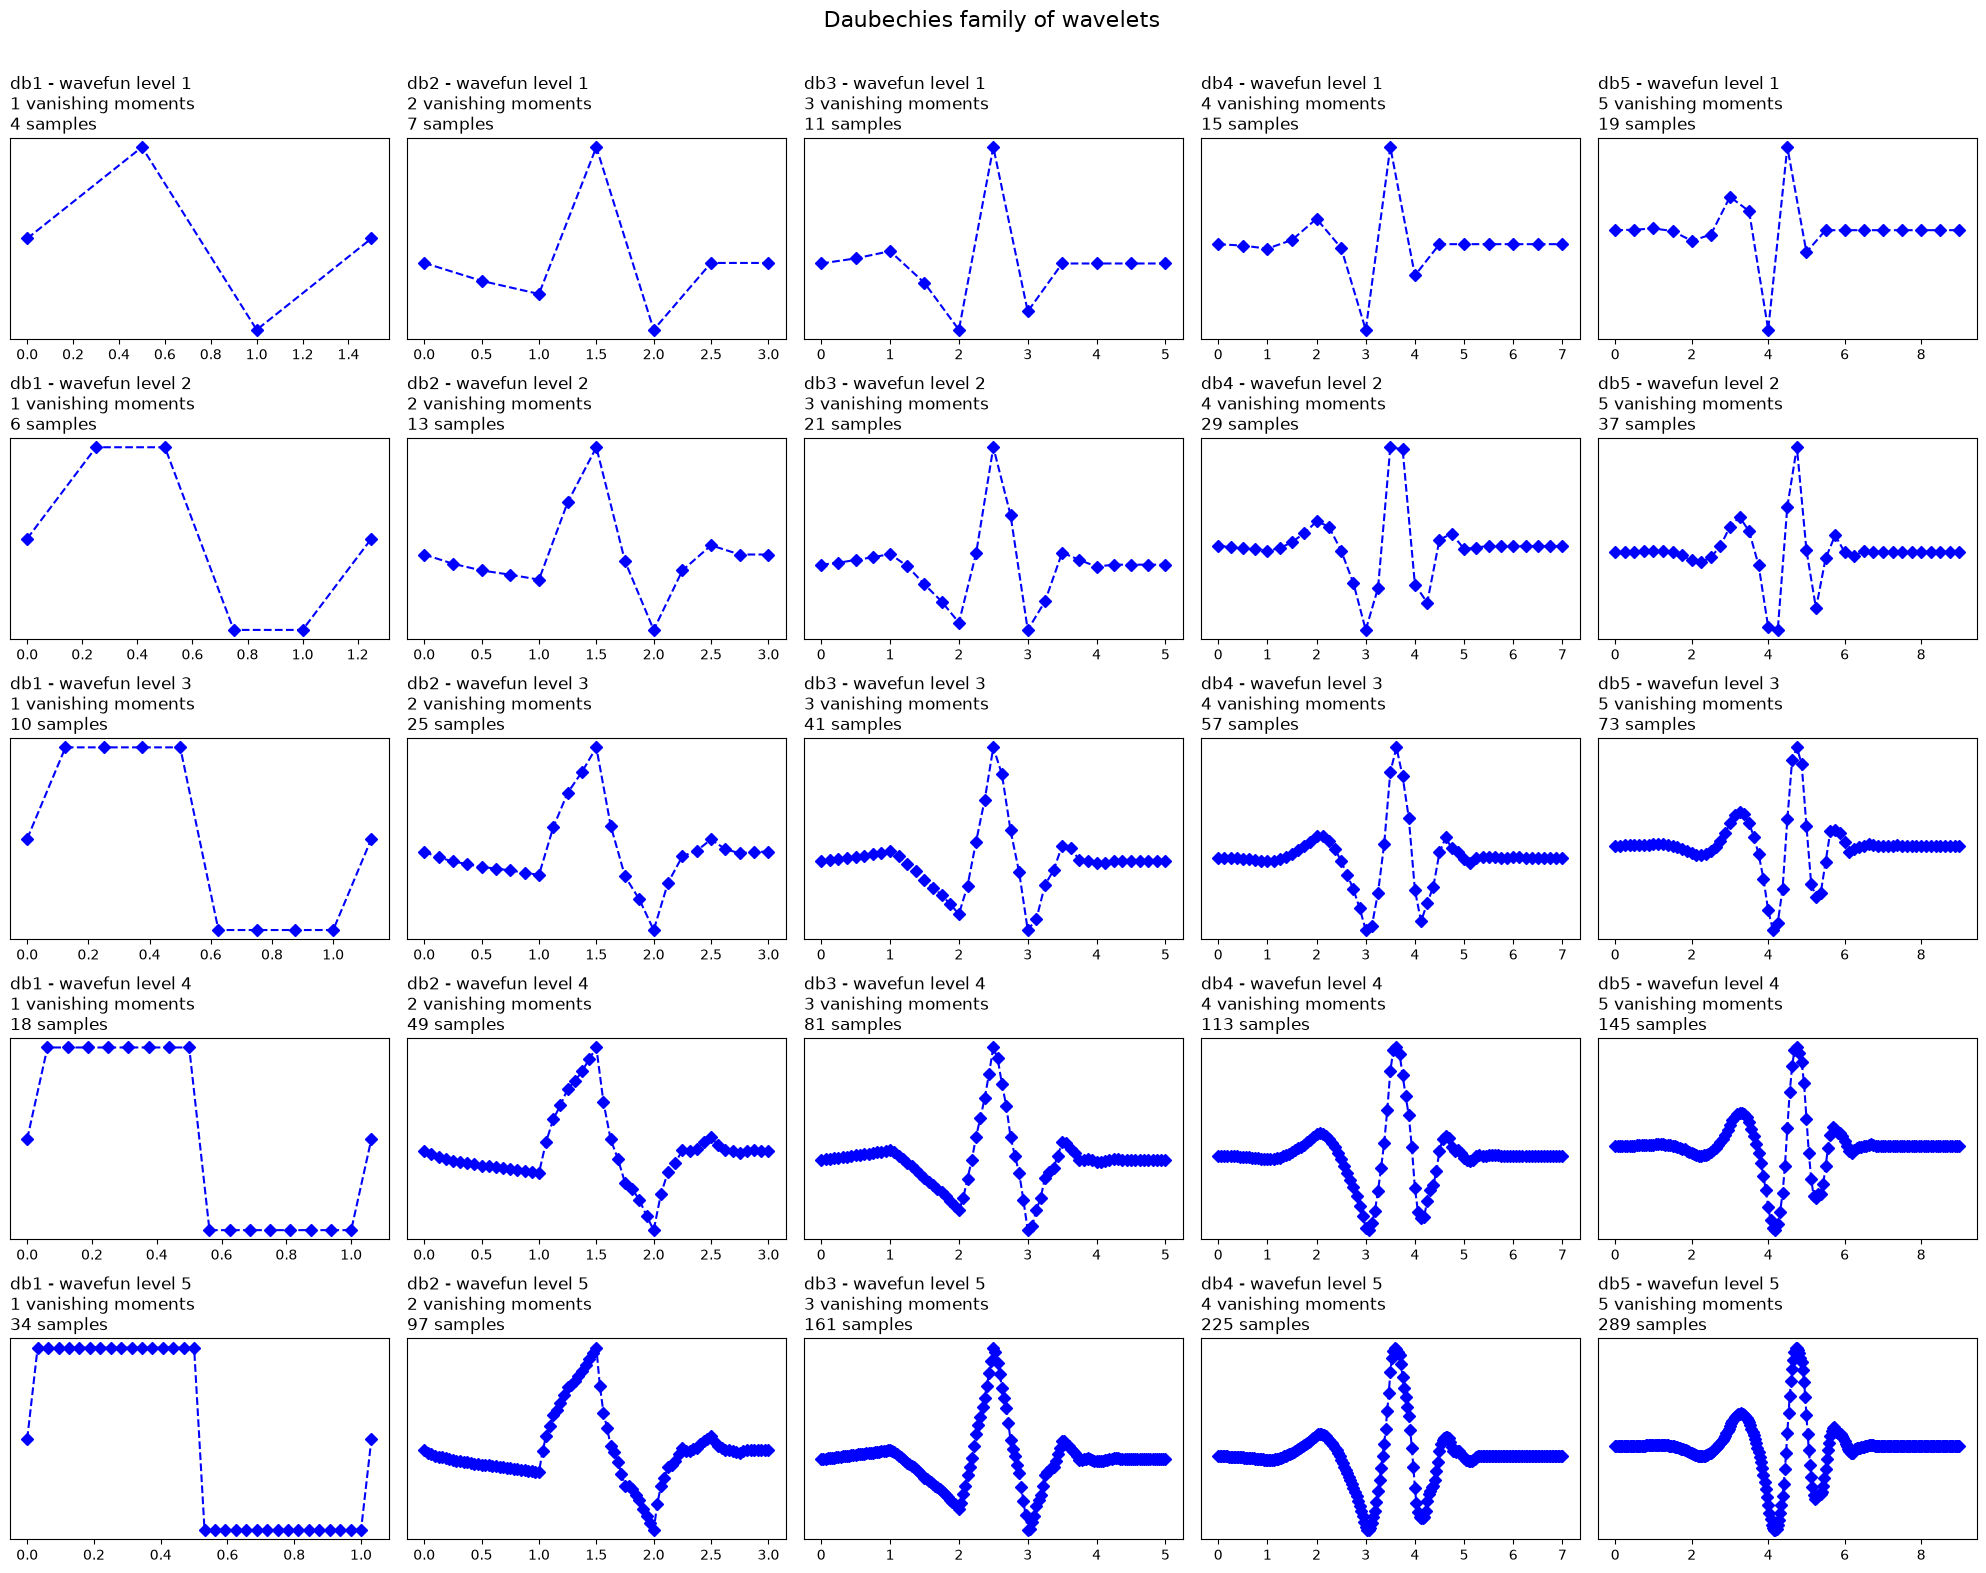

In [20]:
# source-cells: 15
fig, axarr = plt.subplots(ncols=5, nrows=5, figsize=(20,16))
fig.suptitle('Daubechies family of wavelets', fontsize=16)

db_wavelets = [f'db{k}' for k in range(1, 6)]
for col_no, waveletname in enumerate(db_wavelets):
    wavelet = pywt.Wavelet(waveletname)
    no_moments = wavelet.vanishing_moments_psi
    family_name = wavelet.family_name
    for row_no, level in enumerate(range(1,6)):
        scaling_function, wavelet_function, x_values = wavelet.wavefun(level=level)
        axarr[row_no, col_no].set_title("{} - wavefun level {}\n{} vanishing moments\n{} samples".format(
            waveletname, level, no_moments, len(x_values)), loc='left')
        axarr[row_no, col_no].plot(x_values, wavelet_function, 'bD--')
        axarr[row_no, col_no].set_yticks([])
        axarr[row_no, col_no].set_yticklabels([])
plt.tight_layout()
plt.subplots_adjust(top=0.9);

In [21]:
# source-cells: 16

`db3` 有三個消失動差，`db5` 有五個。較高階能消去較高次多項式的影響，但通常需要更長的濾波器，邊界影響也會擴大。

上圖的 `wavefun(level=...)` 控制近似同一個母小波的取樣精細度，level 越高，畫圖的樣本越多。後面 `wavedec(..., level=...)` 才控制**資料分解層數**：每層繼續分解低通分支，係數通常越來越少。省略 `wavedec` 的 level 時，PyWavelets 依資料長度與濾波器長度選取 `dwt_max_level`；它是避免所有係數都受邊界延拓影響的實用上限，仍可要求更深分解，但邊界效應會更明顯。

In [22]:
# source-cells: 17

## CWT：閱讀時間與尺度

In [23]:
# source-cells: 18

CWT 適合觀察頻率隨時間改變的訊號。讀尺度圖時，先確認橫軸時間、縱軸尺度或換算後的 pseudo-frequency，再看亮帶的位置、寬度與持續時間。大尺度小波覆蓋較長區間，靠近訊號兩端時更依賴補值；邊界附近的亮帶要配合支撐範圍判讀。

[A gentle introduction to wavelet for data analysis](https://www.kaggle.com/code/asauve/a-gentle-introduction-to-wavelet-for-data-analysis/notebook)提供 CWT 範例。可沿著母小波、取樣週期與尺度網格讀程式，再用前面的時間–頻率示意理解結果。本章接著使用 DWT 示範可重建的分解與去雜訊。

In [24]:
# source-cells: 19

## DWT：用濾波器分解訊號

In [25]:
# source-cells: 20

DWT 以分析濾波器組把訊號分成近似與細節，並搭配降採樣。保留全部係數時可以重建；若量化、捨棄或縮小部分係數，就能用於壓縮或去雜訊。[這則 DWT 說明](https://dsp.stackexchange.com/a/48141)可對照下面的濾波樹閱讀。

In [26]:
# source-cells: 21

一階分解先做低通與高通濾波，再將兩個分支各降採樣，得到近似 $cA_1$ 與細節 $cD_1$。下一階只繼續分解 $cA_1$，所以較深層描述較粗的尺度。每階係數長度大致減半，精確長度還受濾波器與邊界模式影響。

以最高可表示頻率為 1000 Hz 的理想化濾波樹說明：第一階分成 0–500 與 500–1000 Hz，第二階把低頻分成 0–250 與 250–500 Hz，第三階再分成 0–125 與 125–250 Hz。這些區間只提供尺度直覺；真實小波濾波器的頻率響應有過渡區，並非理想磚牆頻帶。

降採樣可以減少儲存與計算，但單一分支可能含混疊項；可逆濾波器組會在合成時讓這些項相消。分解越深，越多係數受到邊界延拓影響，因此需要配合訊號長度選層數。

In [27]:
# source-cells: 22

(dwt-perfect-reconstruction)=

`pywt.dwt()` 回傳單階的 `(cA, cD)`，可再對 `cA` 繼續分解。`pywt.wavedec()` 則一次取得 `[cA_L, cD_L, ..., cD_1]`：最粗近似放第一項，細節由粗到細排列。

下面先用完整 ECG 與 `db1`、`smooth` 延拓做一次 DWT／IDWT，再以 `wavedec(level=8)` 分解，確認未修改係數時能還原訊號。`smooth` 用邊界趨勢外推，和多階例子採用的預設 `symmetric` 模式不同；各自重建時維持相同模式。

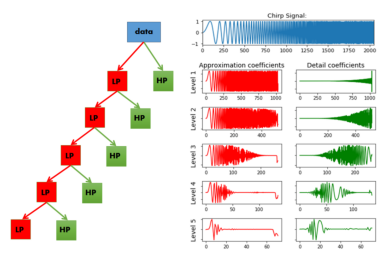

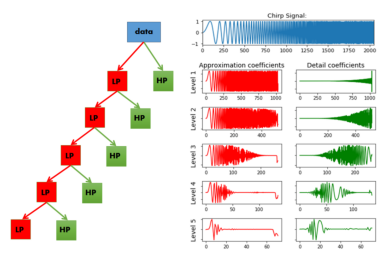

In [28]:
# source-cells: 22
# 原教學示意圖：https://drive.google.com/uc?id=1CBbSFKCbAd1aeHM0Iwr0cqMlPhV2USl8
show_images(ski.io.imread(image_path('ch04-cell22-1.png')))

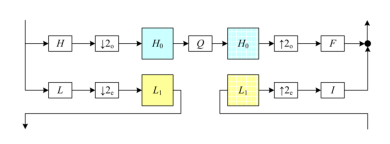

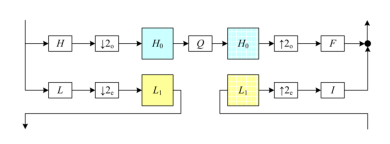

In [29]:
# source-cells: 22
# 原教學示意圖：https://drive.google.com/uc?id=1CSQ4p28-P0LAV94d_cJ-qLHKTw29_S2A
show_images(ski.io.imread(image_path('ch04-cell22-2.png')))

In [30]:
diagram('wavelet-filterbank')

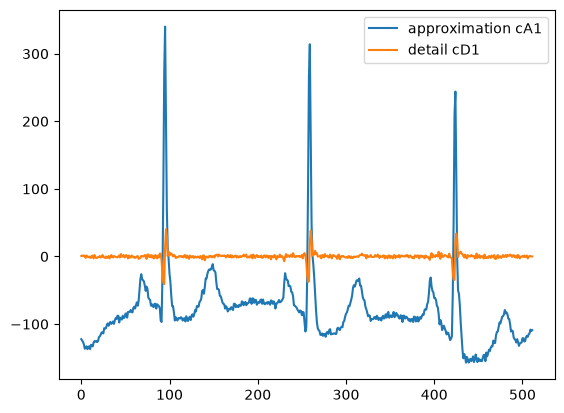

In [31]:
# source-cells: 23
signals = pywt.data.ecg()
(cA1, cD1) = pywt.dwt(signals, 'db1', 'smooth')
reconstructed_signals = pywt.idwt(cA1, cD1, 'db1', 'smooth')

plt.plot(cA1)
plt.plot(cD1);
assert np.allclose(reconstructed_signals[:signals.size], signals)
plt.legend(['approximation cA1', 'detail cD1'])

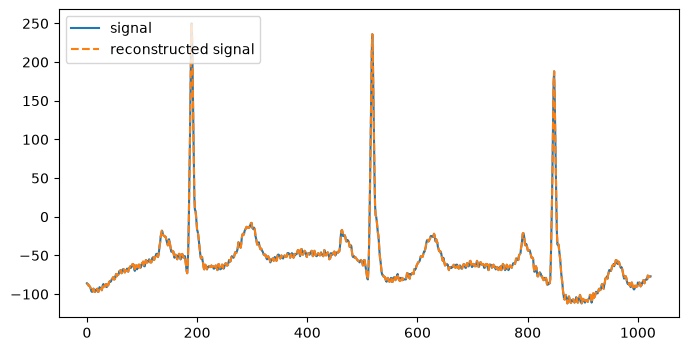

In [32]:
# source-cells: 24
fig, ax = plt.subplots(figsize=(8,4))
ax.plot(signals, label='signal')
ax.plot(reconstructed_signals, label='reconstructed signal', linestyle='--')
ax.legend(loc='upper left');

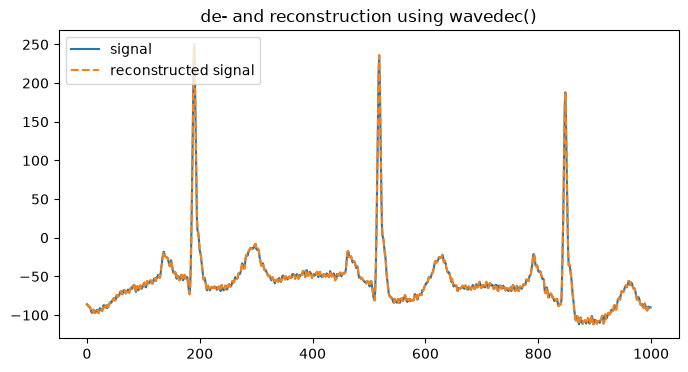

In [33]:
# source-cells: 25
coeffs = pywt.wavedec(signals, 'db1', level=8)
reconstructed_signals = pywt.waverec(coeffs, 'db1')

fig, ax = plt.subplots(figsize=(8,4))
ax.plot(signals[:1000], label='signal')
ax.plot(reconstructed_signals[:1000], label='reconstructed signal', linestyle='--')
ax.legend(loc='upper left')
ax.set_title('de- and reconstruction using wavedec()');
assert np.allclose(reconstructed_signals[:signals.size], signals)

In [34]:
# source-cells: 26

## 修改細節係數：從重建到去雜訊

原封不動的係數能重建輸入；修改係數後，輸出也會改變。若某些細節主要由雜訊構成，降低它們可能改善結果，但微弱訊號也可能一起被縮小。

Soft threshold 的規則是

$$T_\tau(c)=\operatorname{sign}(c)\max(|c|-\tau,0).$$

絕對值不大於閾值的係數變成零，大係數則向零收縮；它沒有移除大係數。Hard threshold 只把小係數設為零，保留大係數原值。下方函式只處理細節，保留最粗近似。函式名 `lowpassfilter` 沿用範例，它實際執行的是小波細節收縮，和固定線性低通濾波不同。

本例閾值設為 `0.1 * max(noisy_signal)`，是依訊號振幅選定的啟發式，沒有把雜訊標準差直接代入風險公式。再用 `db4`、四層分解的 BayesShrink 作比較。

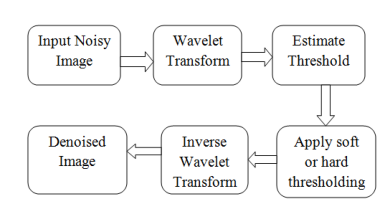

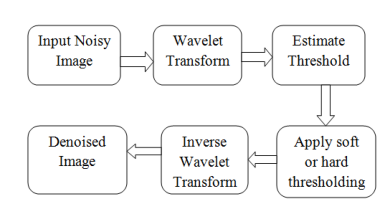

In [35]:
# source-cells: 26
# 原教學示意圖：https://drive.google.com/uc?id=1CKm-W2KyjcBTtq8HJ5BtihIkX8_qFjfw
show_images(ski.io.imread(image_path('ch04-cell26-1.png')))

In [36]:
# source-cells: 27
def lowpassfilter(signal, thresh=0.63, wavelet='db4'):
    """依輸入最大值設定 soft threshold，只縮減細節係數。"""
    signal = np.asarray(signal, dtype=float)
    threshold = thresh * np.nanmax(signal)
    coefficients = pywt.wavedec(signal, wavelet, mode='periodization')
    coefficients[1:] = [
        pywt.threshold(detail, value=threshold, mode='soft')
        for detail in coefficients[1:]
    ]
    return pywt.waverec(coefficients, wavelet, mode='periodization')[:signal.size]

In [37]:
# source-cells: 28
x = pywt.data.ecg().astype(float) / 256
sigma = 0.05  # 雜訊標準差；變異數為 sigma**2
rng = np.random.default_rng(42)
x_noisy = x + sigma * rng.standard_normal(x.size)

In [38]:
# source-cells: 29
rec = lowpassfilter(x_noisy, 0.1)
x_denoise = denoise_wavelet(
    x_noisy, method='BayesShrink', mode='soft', wavelet_levels=4,
    wavelet='db4', channel_axis=None,
)

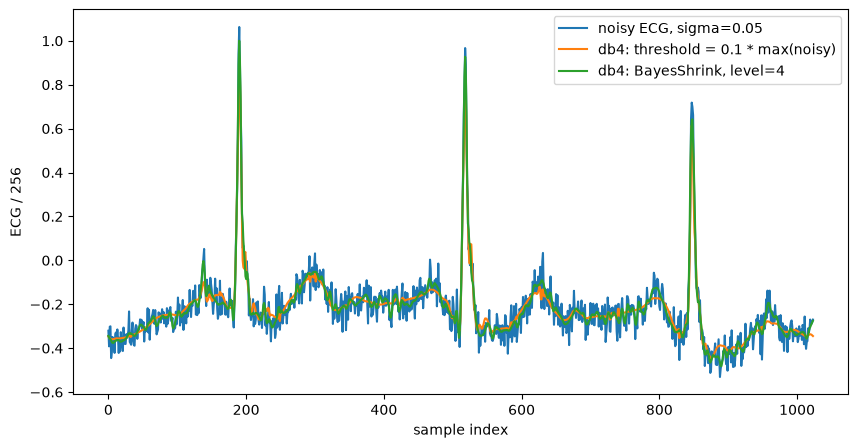

In [39]:
# source-cells: 30
plt.figure(figsize=(10, 5), dpi=100)
plt.plot(x_noisy, label='noisy ECG, sigma=0.05')
plt.plot(rec, label='db4: threshold = 0.1 * max(noisy)')
plt.plot(x_denoise, label='db4: BayesShrink, level=4')
plt.legend()
plt.xlabel('sample index')
plt.ylabel('ECG / 256')
plt.show()

In [40]:
# source-cells: 31

## 二維 DWT：影像的四個子帶

In [41]:
# source-cells: 32

二維 DWT 沿兩軸各做低通與高通，得到近似及三種細節。PyWavelets 回傳 `(cA, (cH, cV, cD))`。下方沿用變數 `LL, LH, HL, HH`，其順序對應這個 API；不同教材對 LH／HL 的命名可能相反，要以套件的軸向定義與圖形確認。

[2D discrete wavelet transformation](https://medium.com/@koushikc2000/2d-discrete-wavelet-transformation-and-its-applications-in-digital-image-processing-using-matlab-1f5c68672de3)用濾波器組介紹二維分解，可對照本節的四子帶。先將 Lucario 與白背景混合並轉成灰階，再使用 `bior1.3`。

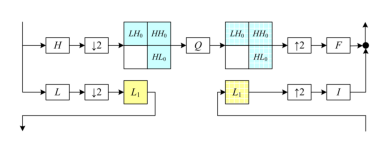

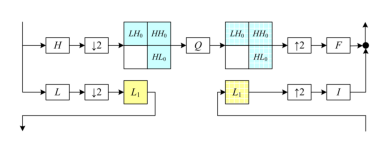

In [42]:
# source-cells: 32
# 原教學示意圖：https://drive.google.com/uc?id=1CCfQ-3lE1A3aHwnuI5rXipH6kF6SRnAr
show_images(ski.io.imread(image_path('ch04-cell32-1.png')))

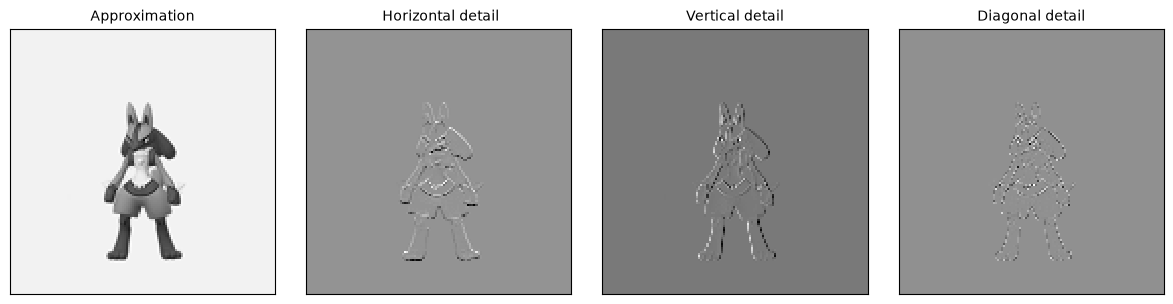

In [43]:
# source-cells: 33
# Load image
original = ski.color.rgb2gray(ski.color.rgba2rgb(ski.io.imread(image_path('lucario.png'))))

# Wavelet transform of image, and plot approximation and details
titles = ['Approximation', ' Horizontal detail',
          'Vertical detail', 'Diagonal detail']
coeffs2 = pywt.dwt2(original, 'bior1.3')
LL, (LH, HL, HH) = coeffs2
fig = plt.figure(figsize=(12, 3))
for i, a in enumerate([LL, LH, HL, HH]):
    ax = fig.add_subplot(1, 4, i + 1)
    ax.imshow(a, interpolation="nearest", cmap=plt.cm.gray)
    ax.set_title(titles[i], fontsize=10)
    ax.set_xticks([])
    ax.set_yticks([])

fig.tight_layout();
restored = pywt.idwt2(coeffs2, 'bior1.3')[:original.shape[0], :original.shape[1]]
assert np.allclose(restored, original)

### 彩色 crop 的 BayesShrink 與 VisuShrink

這次保留 RGB，裁切 `[40:150,80:160]`，加入標準差 0.15 的 Gaussian 雜訊。`random_noise` 預設會把結果截在合法範圍，因此實際殘差分布與未截斷 Gaussian 不完全相同，估計標準差通常較小。固定 seed 42，讓比較可重現。

六格依序顯示含雜訊、BayesShrink、VisuShrink、原圖，以及將 VisuShrink 的 sigma 參數除以 2、4 的結果。各方法在 YCbCr 中處理後換回 RGB；`rescale_sigma=True` 配合內部量尺轉換調整 sigma，無需把它當成雜訊變異數再次平方。PSNR 使用固定 `data_range=1`。

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.0632386511666966..1.0685009843179993].


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0697557886197794..1.0181221136360705].


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.02528630987726416..1.0691057970685949].


Estimated Gaussian noise standard deviation = 0.0965015605454504


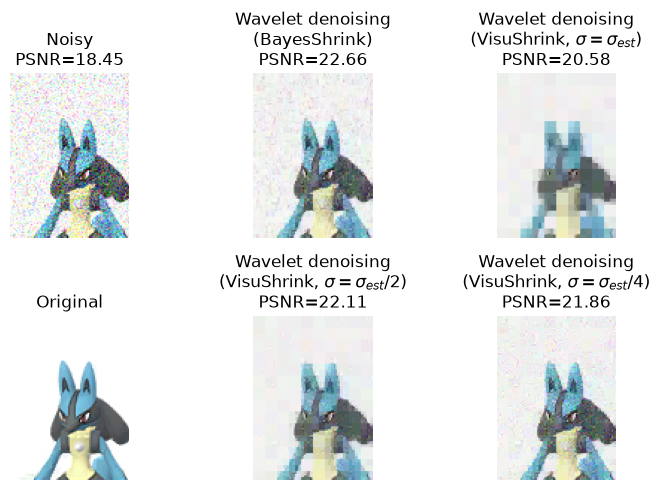

In [44]:
# source-cells: 34
original = ski.util.img_as_float(
    ski.color.rgba2rgb(ski.io.imread(image_path('lucario.png')))
)[40:150, 80:160]

sigma = 0.15
noisy = random_noise(original, var=sigma**2, rng=42)

fig, ax = plt.subplots(nrows=2, ncols=3, figsize=(8, 5),
                       sharex=True, sharey=True)

plt.gray()

# Estimate the average noise standard deviation across color channels.
sigma_est = estimate_sigma(noisy, channel_axis=-1, average_sigmas=True)
# Due to clipping in random_noise, the estimate will be a bit smaller than the
# specified sigma.
print(f'Estimated Gaussian noise standard deviation = {sigma_est}')

im_bayes = denoise_wavelet(noisy, channel_axis=-1, convert2ycbcr=True,
                           method='BayesShrink', mode='soft',
                           rescale_sigma=True)
im_visushrink = denoise_wavelet(noisy, channel_axis=-1, convert2ycbcr=True,
                                method='VisuShrink', mode='soft',
                                sigma=sigma_est, rescale_sigma=True)

# VisuShrink is designed to eliminate noise with high probability, but this
# results in a visually over-smooth appearance.  Repeat, specifying a reduction
# in the threshold by factors of 2 and 4.
im_visushrink2 = denoise_wavelet(noisy, channel_axis=-1, convert2ycbcr=True,
                                 method='VisuShrink', mode='soft',
                                 sigma=sigma_est/2, rescale_sigma=True)
im_visushrink4 = denoise_wavelet(noisy, channel_axis=-1, convert2ycbcr=True,
                                 method='VisuShrink', mode='soft',
                                 sigma=sigma_est/4, rescale_sigma=True)

# Compute PSNR as an indication of image quality
psnr_noisy = peak_signal_noise_ratio(original, noisy, data_range=1.0)
psnr_bayes = peak_signal_noise_ratio(original, im_bayes, data_range=1.0)
psnr_visushrink = peak_signal_noise_ratio(original, im_visushrink, data_range=1.0)
psnr_visushrink2 = peak_signal_noise_ratio(original, im_visushrink2, data_range=1.0)
psnr_visushrink4 = peak_signal_noise_ratio(original, im_visushrink4, data_range=1.0)

ax[0, 0].imshow(noisy)
ax[0, 0].axis('off')
ax[0, 0].set_title(f'Noisy\nPSNR={psnr_noisy:0.4g}')
ax[0, 1].imshow(im_bayes)
ax[0, 1].axis('off')
ax[0, 1].set_title(
    f'Wavelet denoising\n(BayesShrink)\nPSNR={psnr_bayes:0.4g}')
ax[0, 2].imshow(im_visushrink)
ax[0, 2].axis('off')
ax[0, 2].set_title(
    'Wavelet denoising\n(VisuShrink, $\\sigma=\\sigma_{est}$)\n'
     'PSNR=%0.4g' % psnr_visushrink)
ax[1, 0].imshow(original)
ax[1, 0].axis('off')
ax[1, 0].set_title('Original')
ax[1, 1].imshow(im_visushrink2)
ax[1, 1].axis('off')
ax[1, 1].set_title(
    'Wavelet denoising\n(VisuShrink, $\\sigma=\\sigma_{est}/2$)\n'
     'PSNR=%0.4g' % psnr_visushrink2)
ax[1, 2].imshow(im_visushrink4)
ax[1, 2].axis('off')
ax[1, 2].set_title(
    'Wavelet denoising\n(VisuShrink, $\\sigma=\\sigma_{est}/4$)\n'
     'PSNR=%0.4g' % psnr_visushrink4)
fig.tight_layout();

In [45]:
# source-cells: 35

## 如何比較閾值與重建結果？

BayesShrink 依各子帶的訊號與雜訊估計調整閾值。VisuShrink 使用 universal threshold 的想法，典型形式為 $\tau=\widehat\sigma\sqrt{2\log N}$，N 是使用的樣本數。在白高斯雜訊假設下，它傾向較強地壓低小係數，有時也會抹平細節。

Lucario 的比較依序使用估計標準差、其一半與四分之一。改小輸入標準差會降低收縮強度，可能保留更多細節，也會留下更多雜訊；這是參數敏感度比較，沒有改變實際加入的雜訊。PSNR 以原乾淨 crop 為參考，數值越高表示此範圍下的均方誤差越低，仍要看眼睛、輪廓等局部細節。

[A guide for using the Wavelet Transform in Machine Learning](https://ataspinar.com/2018/12/21/a-guide-for-using-the-wavelet-transform-in-machine-learning/)把小波家族、CWT 與 DWT 連在一起；[小波介紹影片](https://www.youtube.com/watch?v=QX1-xGVFqmw)可配合本章示意圖觀看。閱讀時分清 `wavefun` 的取樣精細度與 DWT 的資料分解層數。

In [46]:
# source-cells: 36

## 延伸閱讀

In [47]:
# source-cells: 37

- **Szeliski, R.（2022），*Computer Vision: Algorithms and Applications*, 2nd ed.** [作者網站](https://szeliski.org/Book/)；以第 3.4 節 Fourier、第 3.5 節金字塔與小波、第 7.1 節影像對齊連起頻域、尺度及影像比較 {cite}`szeliski2022`。
- **PyWavelets 官方文件**：[小波物件與 wavefun](https://pywavelets.readthedocs.io/en/stable/ref/wavelets.html)、[DWT](https://pywavelets.readthedocs.io/en/stable/ref/dwt-discrete-wavelet-transform.html)、[CWT](https://pywavelets.readthedocs.io/en/stable/ref/cwt.html)。對照回傳值、邊界模式、尺度與 pseudo-frequency；兩種 level 的意義要分開。
- **scikit-image restoration 文件**：[denoise_wavelet](https://scikit-image.org/docs/stable/api/skimage.restoration.html#skimage.restoration.denoise_wavelet)。查看 BayesShrink、VisuShrink、sigma、channel_axis 與色彩轉換的參數，對照本章 Lucario 的五種結果。
- **Dey, S.（2018），*Hands-On Image Processing with Python*.** [配套程式](https://github.com/PacktPublishing/Hands-On-Image-Processing-with-Python)提供影像處理與小波範例，可由相應章節對照資料讀取與重建。
- **Stanford／課本延伸**：先重看上一章的頻域與金字塔，再用上述官方文件核對小波家族；本章前面保留的 Kaggle 教學與時間–頻率影片，適合作為不同角度的補充閱讀。